# Predicting Student Performance
Given a practice dataset of past student performance.
Using single variable regression but no advanced functions (for now) to predict future student performance.
Student Dataset downloaded from Kaggle.

In [1]:
#imports
import pandas as pd  # for reading .csv data
import numpy as np  # for vectors
import matplotlib.pyplot as plt # for plotting data

In [2]:
df = pd.read_csv("Student_Performance.csv") 
print(df.head()) # see columns

   Hours Studied  Previous Scores Extracurricular Activities  Sleep Hours  \
0              7               99                        Yes            9   
1              4               82                         No            4   
2              8               51                        Yes            7   
3              5               52                        Yes            5   
4              7               75                         No            8   

   Sample Question Papers Practiced  Performance Index  
0                                 1               91.0  
1                                 2               65.0  
2                                 2               45.0  
3                                 2               36.0  
4                                 5               66.0  


Note: Since this is my first attempt, I will only use single variable regression on Hours Studied

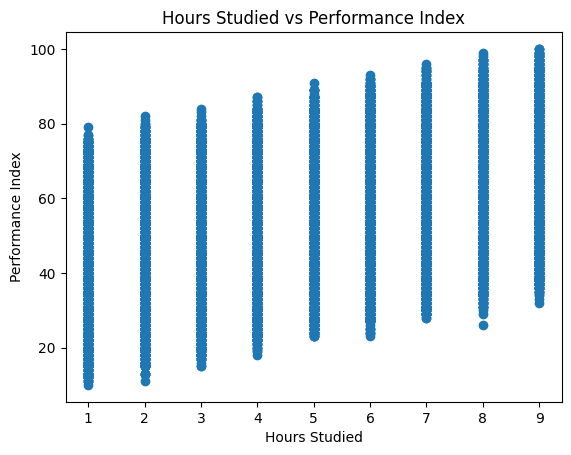

In [3]:
x = df["Hours Studied"].to_numpy()
y = df["Performance Index"].to_numpy()

plt.scatter(x, y)
plt.xlabel("Hours Studied")
plt.ylabel("Performance Index")
plt.title("Hours Studied vs Performance Index")
plt.show()

Observation: There is a clear upwards trend, but since we are using only 1 parameter for x as of now, there is a big variance per hour studied. the goal is to now use linear regression to make a line of best fit, in order to predict where ones grade will be give the # of hours studied.

Plan: This file is to not use sk-learn for my own learning purposes, after, we will use it and after that, we will incorporate more variables to get a better prediction.

In [4]:
# computing the cost function
def compute_cost(x, y, w, b):
    m = x.shape[0]
    cost = 0
    for i in range(m):
        f = w*x[i] + b
        cost += (f-y[i])**2
    cost = cost * (1/(2*m))
    return cost

In [5]:
# implementing gradient descent
def compute_gradient(x, y, w, b):
    m = x.shape[0]
    dj_dw = 0
    dj_db = 0
    for i in range(m):
        f = w*x[i] + b
        dj_dw += (f-y[i])*x[i]
        dj_db += (f-y[i])
    dj_dw *= 1/m
    dj_db *= 1/m
    return dj_dw, dj_db

In [6]:
# given the 2 functions above we can now implement the alogrithm
def gradient_descent_algo(x, y, w, b, alpha, num_iters):
    cost_values = []
    for i in range(num_iters):
        if (i % 100) == 0:
            cost_values.append(compute_cost(x, y, w, b))
        dw, db = compute_gradient(x, y, w, b)
        local_w = w - alpha * dw
        local_b = b - alpha * db
        w, b = local_w, local_b
    return w, b, cost_values

All helper functions have been completed

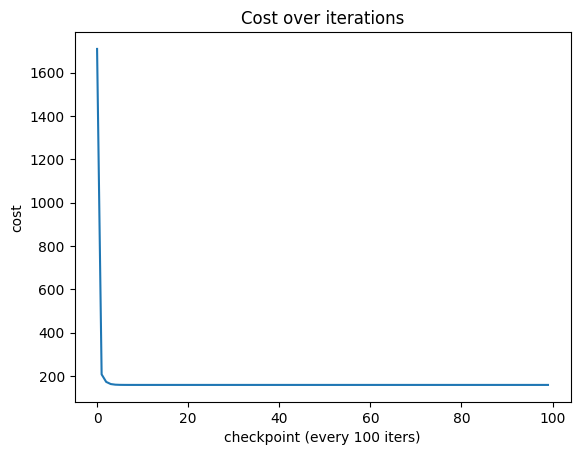

In [7]:
w_final, b_final, cost_values = gradient_descent_algo(x, y, 0, 0, 0.03, 10000) # 0 and 0 are the intial weights for w and b, the learning rate is 0.01

plt.plot(cost_values)
plt.xlabel("checkpoint (every 100 iters)")
plt.ylabel("cost")
plt.title("Cost over iterations")
plt.show()

As you can see, after 1000 iterations of the gradient descent algo, the cost function has been minimized. I suppose that we could have used less iterations than 1000 to get very similar results. We can now use our final w and b values to plot the line of best fit and make predictions

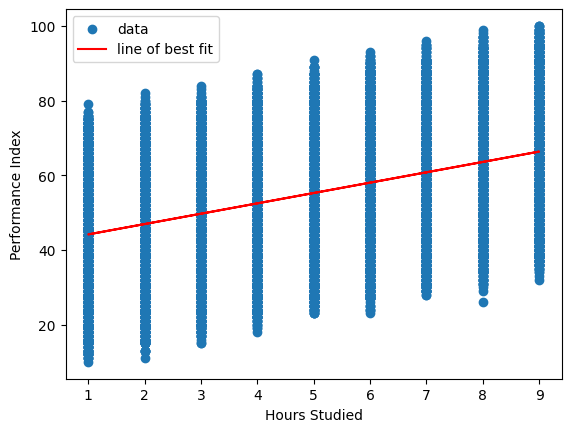

In [8]:
plt.scatter(x, y, label="data")
plt.plot(x, w_final * x + b_final, color="red", label="line of best fit")
plt.xlabel("Hours Studied")
plt.ylabel("Performance Index")
plt.legend()
plt.show()

Due to the large variance of the y values and the fact that we only used 1 variable, this won't be as effective as using multivariable regression, but for my own learning purpose, this shows a big step. Here are some predictions of your performance index given hours studied.

In [9]:
#predictions:

print(f"Given 4 hours of studying, the preformance index is predicted to be {w_final*4+b_final}.")

print(f"Given 7 hours of studying, the preformance index is predicted to be {w_final*7+b_final}.")

Given 4 hours of studying, the preformance index is predicted to be 52.4714259214158.
Given 7 hours of studying, the preformance index is predicted to be 60.790614395332874.


## Validation against scikit-learn
We will use sk-learn now to prove that my findings were right

In [10]:
from sklearn.linear_model import LinearRegression

X_sklearn = x.reshape(-1, 1)  # turn into 2d arrays for sk-learn

model = LinearRegression()  # use LinearRegression() in sk-learn to do all the heavy lifting
model.fit(X_sklearn, y)

print("sklearn weight:", model.coef_[0])
print("sklearn bias:  ", model.intercept_)
print("your w_final:  ", w_final)
print("your b_final:  ", b_final)

sklearn weight: 2.7730628246389526
sklearn bias:   41.37917462286018
your w_final:   2.7730628246390245
your b_final:   41.3791746228597


Initally my manual final values of w and b were not consistent with sk-learn, so i will increase the alpha and the number of iterations: 
- sklearn weight: 2.7730628246389526
- sklearn bias:   41.37917462286018
- your w_final:   3.5739466890088014
- your b_final:   36.33827597865793

After changing the number of iterations to 10000 from 1000 and the learning rate to 0.03 from 0.01, my manual models prediction is now almost identical to sk-learn's:
- sklearn weight: 2.7730628246389526
- sklearn bias:   41.37917462286018
- your w_final:   2.7730628246390245
- your b_final:   41.3791746228597

I note that the 10000 is a ridiculous number of iterations for what the model is trying to do, so I will use feature standardizzation to fix this to be able to decrease the number of iterations and even increase the learning rate

## Standardization

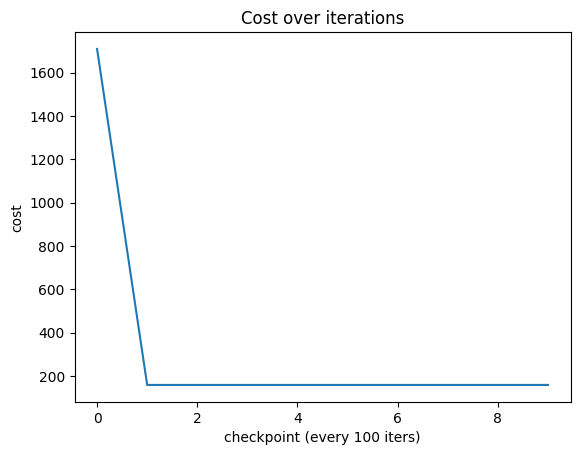

In [11]:
x_std = (x - x.mean()) / x.std()

w_final, b_final, cost_values = gradient_descent_algo(x_std, y, 0, 0, 0.1, 1000) # 0 and 0 are the intial weights for w and b, the learning rate is 0.01

plt.plot(cost_values)
plt.xlabel("checkpoint (every 100 iters)")
plt.ylabel("cost")
plt.title("Cost over iterations")
plt.show()

In [12]:
#comapre to skit-learn:
X_sklearn = x_std.reshape(-1, 1)  # turn into 2d arrays for sk-learn

model = LinearRegression()  # use LinearRegression() in sk-learn to do all the heavy lifting
model.fit(X_sklearn, y)

print("sklearn weight:", model.coef_[0])
print("sklearn bias:  ", model.intercept_)
print("your w_final:  ", w_final)
print("your b_final:  ", b_final)

sklearn weight: 7.179956939438786
sklearn bias:   55.2248
your w_final:   7.179956939438879
your b_final:   55.22479999999996


Even with a lower number of iterations 10000 -> 1000 and a much higher learning rate, standardization lead to me to have the same outcome! This is very good, we will now implement the regression for all the variables.

## Multivariable regression

In [13]:
df["Extracurricular Activities"] = (df["Extracurricular Activities"] == "Yes").astype(int) #Yes = 1, No = 0

X = df[["Hours Studied", "Previous Scores", "Extracurricular Activities", "Sleep Hours", "Sample Question Papers Practiced"]].to_numpy()  #vectorize

X_std = (X - X.mean(axis=0)) / X.std(axis=0)  # standardize

Now I need to make new functions since there are more variables, I'll skip the iterative versions and go straight to using .dot()

In [14]:
# computing the cost function
def compute_cost(x, y, w, b):
    m = x.shape[0]
    cost = 0
    for i in range(m):
        f = np.dot(w, x[i]) + b
        cost += (f-y[i])**2
    cost = cost * (1/(2*m))
    return cost

In [15]:
# implementing gradient descent
def compute_gradient(x, y, w, b):
    m = x.shape[0]
    dj_dw = np.zeros(x.shape[1])
    dj_db = 0
    for i in range(m):
        f = np.dot(w, x[i]) + b
        dj_dw += (f-y[i])*x[i]
        dj_db += (f-y[i])
    dj_dw *= 1/m
    dj_db *= 1/m
    return dj_dw, dj_db

In [16]:
# given the 2 functions above we can now implement the alogrithm
def gradient_descent_algo(x, y, w, b, alpha, num_iters):
    cost_values = []
    for i in range(num_iters):
        if (i % 100) == 0:
            cost_values.append(compute_cost(x, y, w, b))
        dw, db = compute_gradient(x, y, w, b)
        local_w = w - alpha * dw
        local_b = b - alpha * db
        w, b = local_w, local_b
    return w, b, cost_values

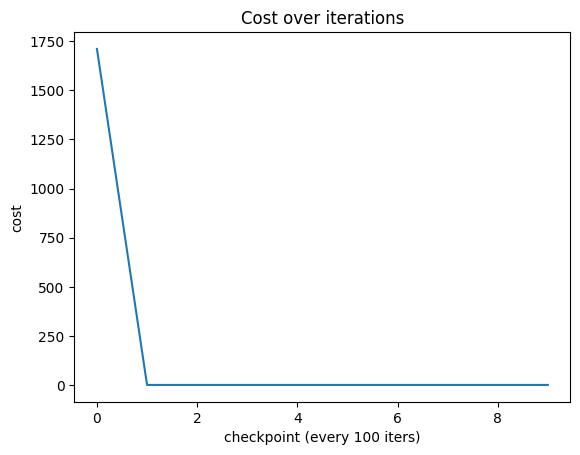

In [17]:
w_init = np.zeros(X_std.shape[1])
w_final, b_final, cost_values = gradient_descent_algo(X_std, y, w_init, 0, 0.1, 1000)

plt.plot(cost_values)
plt.xlabel("checkpoint (every 100 iters)")
plt.ylabel("cost")
plt.title("Cost over iterations")
plt.show()

In [18]:
model = LinearRegression()
model.fit(X_std, y)
print("sklearn weights:", model.coef_)      # 5 numbers
print("your w_final:   ", w_final)           # 5 numbers
print("sklearn bias:   ", model.intercept_)
print("your b_final:   ", b_final)

sklearn weights: [ 7.38688215 17.66197609  0.30643222  0.81492275  0.55567035]
your w_final:    [ 7.38688215 17.66197609  0.30643222  0.81492275  0.55567035]
sklearn bias:    55.2248
your b_final:    55.22479999999997


Now that the multivarite version has been verifed by scikit-learn, we can make a graph of actual vs predicted values to see the accuracy of the predictions when using multivariate regression

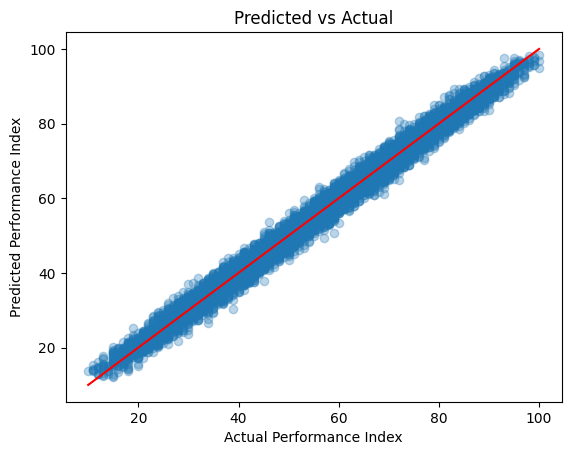

In [19]:
predictions = np.array([np.dot(w_final, X_std[i]) + b_final for i in range(X_std.shape[0])])

plt.scatter(y, predictions, alpha=0.3)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color="red")  # perfect-prediction line
plt.xlabel("Actual Performance Index")
plt.ylabel("Predicted Performance Index")
plt.title("Predicted vs Actual")
plt.show()

This is very good. One last think we can use R^2 to show the accuracy

In [20]:
from sklearn.metrics import r2_score
print("R²:", r2_score(y, predictions))

R²: 0.9887523323780958


R²: 0.9887523323780958 -> is very close to 1 so the model is doing a very good job

## Conclusions:

In this notebook I built linear regression from scratch to predict student performance index. I started with a single feature (hours studied) and wrote my own cost function, gradient function, and gradient descent loop. The single variable model worked but wasn't very accurate since one feature can't explain much of the variance.

Along the way I ran into a few things worth noting:
- My manual w and b didn't match sk-learn at first. I fixed this by increasing the iterations and the learning rate so gradient descent had room to converge.
- When I pushed the learning rate too high (0.1), the cost blew up to infinity instead of going down. This showed me that too big of a learning rate causes divergence.
- I used feature standardization to fix this. After standardizing, gradient descent converged with way fewer iterations (1000 instead of 10000) and a higher learning rate, and still matched sk-learn exactly.

I then extended everything to multivariable regression using all 5 features. The math went from scalar multiplication to dot products, and the gradient became a vector. Using standardized weights, I could also see which features mattered most: previous scores had by far the biggest weight (~17.7), followed by hours studied (~7.4), while the other three barely contributed.

The final multivariable model gave an R² of 0.9888, meaning it explains about 99% of the variance in performance index. The predicted vs actual plot also shows the points sitting tightly along the perfect prediction line. This is a big step up from the single feature version and validates that adding more relevant features improved the model.